# Week 02: Customer Churn Prediction (Telecom)

## Business Understanding
Customer churn occurs when customers stop doing business with a company. For telecommunications companies, retaining customers is often more cost-effective than acquiring new ones. 

**Goal:** Build a model to predict which customers are likely to churn based on their usage patterns and demographics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import shap
import pickle

# Set visual style
sns.set_theme(style="whitegrid")
%matplotlib inline

c:\Users\fasee\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Day 1: Dataset Loading & Inspection

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully!")

Dataset loaded successfully!


## Day 2: Feature Engineering

In [3]:
# 1. Handle missing values in TotalCharges (replace blank strings with NaN and then 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. Tenure grouping
def tenure_group(tenure):
    if tenure <= 12:
        return '0-1 Year'
    elif tenure <= 24:
        return '1-2 Years'
    elif tenure <= 48:
        return '2-4 Years'
    elif tenure <= 60:
        return '4-5 Years'
    else:
        return '> 5 Years'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

# 3. LTV (Lifetime Value) Approximation
df['LTV'] = df['MonthlyCharges'] * df['tenure']

# 4. Encoding categorical variables
le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-hot encoding for multi-class features
df_processed = pd.get_dummies(df.drop(['customerID', 'tenure'], axis=1))

print("Feature engineering complete.")
df_processed.head()

Feature engineering complete.


,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,LTV,...,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_0-1 Year,TenureGroup_1-2 Years,TenureGroup_2-4 Years,TenureGroup_4-5 Years,TenureGroup_> 5 Years
0,0,0,1,0,0,1,29.85,29.85,0,29.85,...,False,False,False,True,False,True,False,False,False,False
1,1,0,0,0,1,0,56.95,1889.50,0,1936.30,...,False,False,False,False,True,False,False,True,False,False
2,1,0,0,0,1,1,53.85,108.15,1,107.70,...,False,False,False,False,True,True,False,False,False,False
3,1,0,0,0,0,0,42.30,1840.75,0,1903.50,...,False,True,False,False,False,False,False,True,False,False
4,0,0,0,0,1,1,70.70,151.65,1,141.40,...,False,False,False,True,False,True,False,False,False,False


## Day 3: Train Logistic Regression & Random Forest

In [4]:
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

c:\Users\fasee\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



## Day 4: Hyperparameter Tuning & SHAP Explainability

In [5]:
# Hyperparameter Tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Params: {grid_search.best_params_}")

# Save the model for Day 5 dashboard
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
with open('columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved as churn_model.pkl")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Model saved as churn_model.pkl


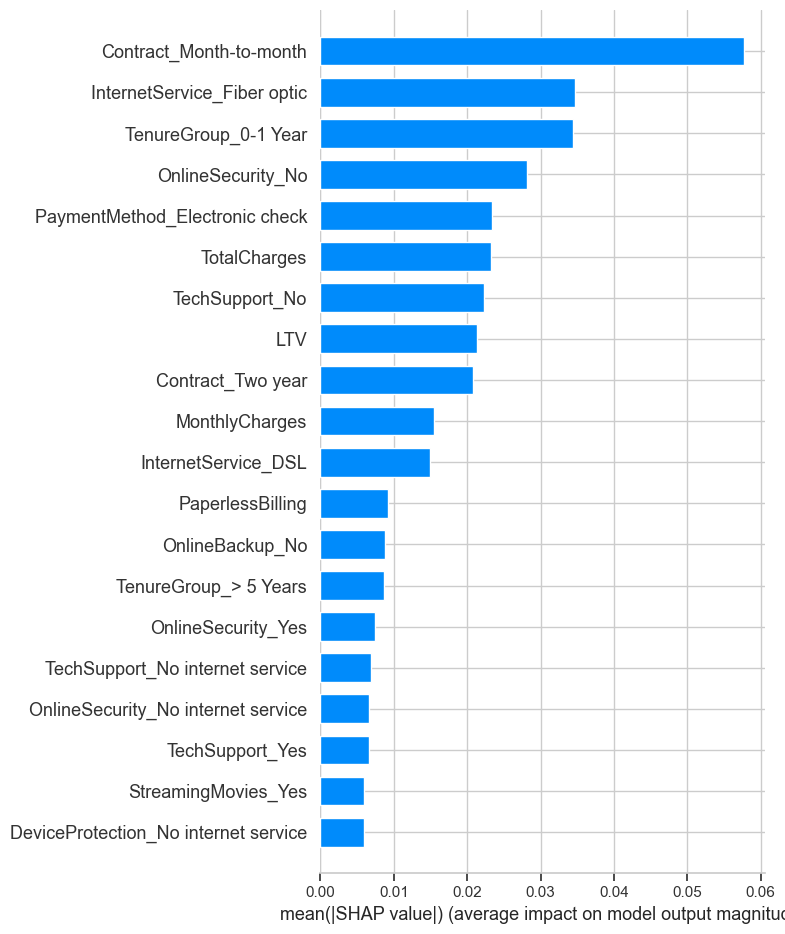

In [7]:
# SHAP Explainability (Updated Fix)
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))

# Handle different SHAP versions/formats
if isinstance(shap_values, list):
    # For older SHAP versions (returns a list of arrays for each class)
    shap.summary_plot(shap_values[1], X_test, plot_type="bar")
elif len(shap_values.shape) == 3:
    # For newer SHAP versions that return a 3D array (samples, features, classes)
    shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")
else:
    # Fallback for standard 2D arrays
    shap.summary_plot(shap_values, X_test, plot_type="bar")


## Day 5: Dashboard Creation (See app.py)
The model has been saved. We will now create a Streamlit app to serve predictions.